# Image Preprocessing
## ICT3212 - Introduction to Intelligent Systems
### Facial Emotion Detection System (Inflators)

This notebook covers the mandatory image preprocessing steps:
1. **Resize** images to a fixed size (48×48).
2. **Normalize** pixel values (0–1 range).
3. **Convert** images to tensors.
4. **Split** dataset into Training and Testing sets (80/20).

---
## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow Version : {tf.__version__}')
print(f'NumPy Version      : {np.__version__}')
print(f'OpenCV Version     : {cv2.__version__}')
print('\nAll libraries imported successfully!')

TensorFlow Version : 2.20.0
NumPy Version      : 2.4.2
OpenCV Version     : 4.13.0

All libraries imported successfully!


---
## 2. Load Raw Data from CSV

In [2]:
# Load FER-2013 dataset
CSV_PATH = 'data/fer2013.csv'
df = pd.read_csv(CSV_PATH)

# Define emotion mappings
ORIGINAL_LABELS = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}
EMOTION_LABELS = {0: 'Angry', 1: 'Fear', 2: 'Happy', 3: 'Sad', 4: 'Surprise', 5: 'Neutral'}

print(f'Raw dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Raw dataset shape: (35887, 3)
Columns: ['emotion', 'pixels', 'Usage']


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training


In [3]:
# Filter out Disgust class (label 1) and remap labels
df_filtered = df[df['emotion'] != 1].copy()
LABEL_MAP = {0: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
df_filtered['emotion'] = df_filtered['emotion'].map(LABEL_MAP)

print(f'Filtered dataset shape: {df_filtered.shape}')
print(f'Number of classes: {df_filtered["emotion"].nunique()}')
print(f'\nClass distribution:')
for label_id, count in df_filtered['emotion'].value_counts().sort_index().items():
    print(f'  {label_id} ({EMOTION_LABELS[label_id]}): {count} images')

Filtered dataset shape: (35340, 3)
Number of classes: 6

Class distribution:
  0 (Angry): 4953 images
  1 (Fear): 5121 images
  2 (Happy): 8989 images
  3 (Sad): 6077 images
  4 (Surprise): 4002 images
  5 (Neutral): 6198 images


---
## 3. Step 1 — Resize Images to a Fixed Size

The FER-2013 images are originally **48×48 pixels**. We parse each pixel string and reshape it into a 48×48 image array. We also demonstrate resizing to other dimensions to show the process.

**Target Size:** `48 × 48 pixels` (matching the original dataset dimensions, which is the standard input for emotion detection CNNs).

In [4]:
# Parse pixel strings into image arrays
TARGET_SIZE = (48, 48)

print(f'Target image size: {TARGET_SIZE[0]} x {TARGET_SIZE[1]} pixels')
print(f'Processing {len(df_filtered)} images...\n')

images = []
labels = []

for idx, row in df_filtered.iterrows():
    # Parse pixel string to numpy array
    pixel_values = np.array([int(p) for p in row['pixels'].split(' ')], dtype=np.uint8)
    image = pixel_values.reshape(48, 48)
    
    # Resize to target size (48x48 in this case)
    # Using cv2.resize to demonstrate the resizing step
    image_resized = cv2.resize(image, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    
    images.append(image_resized)
    labels.append(row['emotion'])

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

print(f'✅ Step 1 Complete: Images Resized')
print(f'   Images array shape : {images.shape}')
print(f'   Labels array shape : {labels.shape}')
print(f'   Each image size    : {images.shape[1]} x {images.shape[2]} pixels')
print(f'   Data type          : {images.dtype}')
print(f'   Pixel range        : [{images.min()}, {images.max()}]')

Target image size: 48 x 48 pixels
Processing 35340 images...

✅ Step 1 Complete: Images Resized
   Images array shape : (35340, 48, 48)
   Labels array shape : (35340,)
   Each image size    : 48 x 48 pixels
   Data type          : uint8
   Pixel range        : [0, 255]


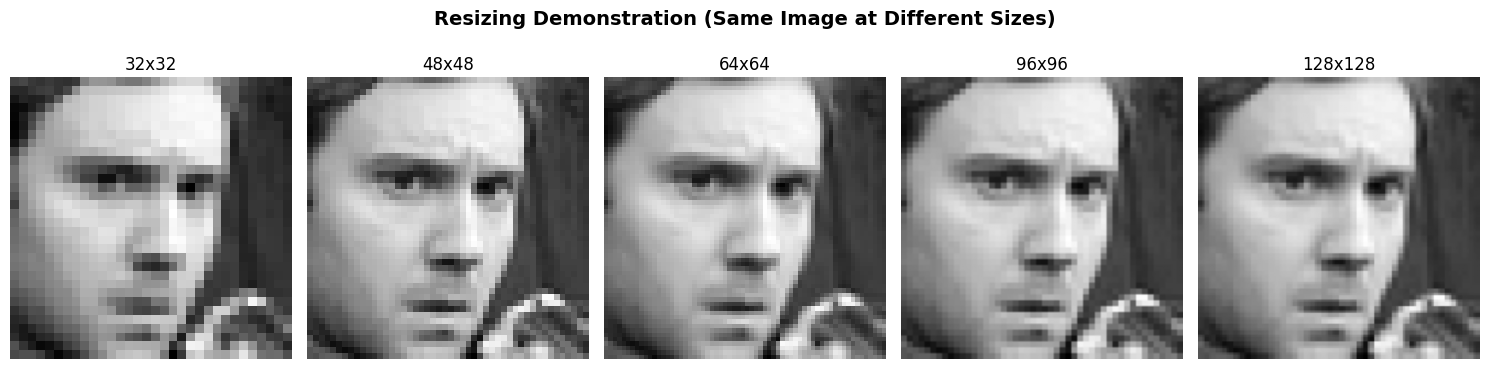

We use 48x48 as it is the native resolution of FER-2013 and avoids quality loss.


In [5]:
# Demonstrate resizing to different dimensions
sample_image = images[0]

sizes = [(32, 32), (48, 48), (64, 64), (96, 96), (128, 128)]
fig, axes = plt.subplots(1, len(sizes), figsize=(15, 4))
fig.suptitle('Resizing Demonstration (Same Image at Different Sizes)', fontsize=14, fontweight='bold')

for i, size in enumerate(sizes):
    resized = cv2.resize(sample_image, size, interpolation=cv2.INTER_AREA)
    axes[i].imshow(resized, cmap='gray')
    axes[i].set_title(f'{size[0]}x{size[1]}', fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.show()
print('We use 48x48 as it is the native resolution of FER-2013 and avoids quality loss.')

---
## 4. Step 2 — Normalize Pixel Values

Raw pixel values range from **0 to 255**. Neural networks perform better when input values are scaled to a smaller range. We normalize to **[0, 1]** by dividing by 255.0.

**Formula:** `normalized_pixel = pixel_value / 255.0`

In [6]:
# Show BEFORE normalization
print('=== BEFORE Normalization ===')
print(f'Data type  : {images.dtype}')
print(f'Min pixel  : {images.min()}')
print(f'Max pixel  : {images.max()}')
print(f'Mean pixel : {images.mean():.2f}')
print(f'Std pixel  : {images.std():.2f}')

=== BEFORE Normalization ===
Data type  : uint8
Min pixel  : 0
Max pixel  : 255
Mean pixel : 129.30
Std pixel  : 65.09


In [7]:
# Normalize pixel values to [0, 1]
images_normalized = images.astype('float32') / 255.0

print('=== AFTER Normalization ===')
print(f'Data type  : {images_normalized.dtype}')
print(f'Min pixel  : {images_normalized.min()}')
print(f'Max pixel  : {images_normalized.max()}')
print(f'Mean pixel : {images_normalized.mean():.4f}')
print(f'Std pixel  : {images_normalized.std():.4f}')
print(f'\n✅ Step 2 Complete: Pixel Values Normalized to [0, 1]')

=== AFTER Normalization ===
Data type  : float32
Min pixel  : 0.0
Max pixel  : 1.0
Mean pixel : 0.5070
Std pixel  : 0.2553

✅ Step 2 Complete: Pixel Values Normalized to [0, 1]


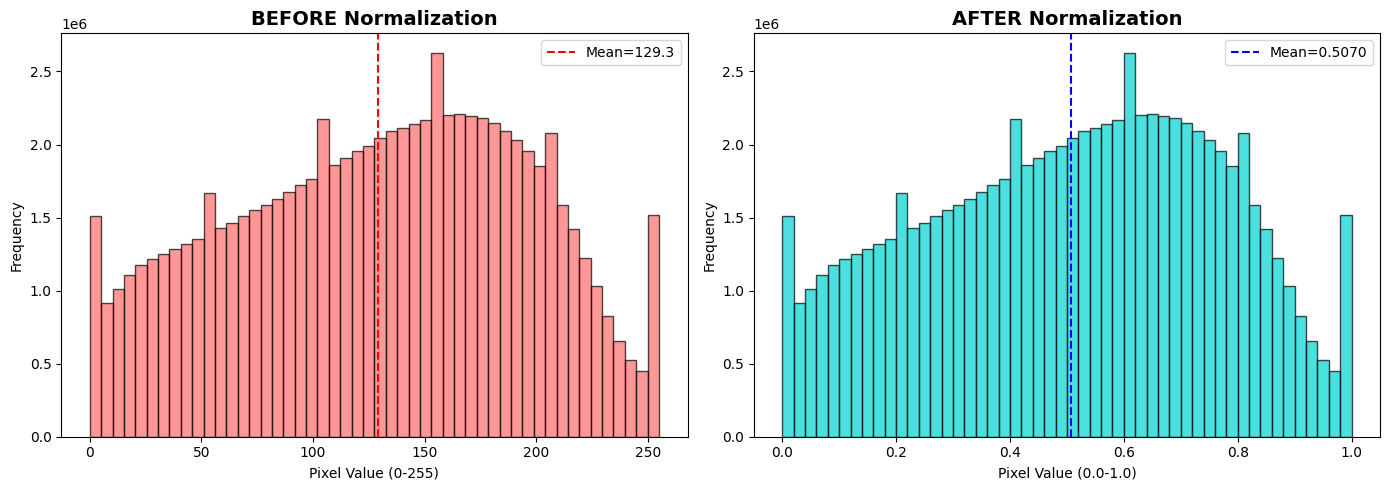

Chart saved as normalization_comparison.png


In [8]:
# Visualize: Before vs After normalization (pixel distribution)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].hist(images.flatten(), bins=50, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[0].set_title('BEFORE Normalization', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Pixel Value (0-255)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=images.mean(), color='red', linestyle='--', label=f'Mean={images.mean():.1f}')
axes[0].legend()

# After
axes[1].hist(images_normalized.flatten(), bins=50, color='#00D2D3', edgecolor='black', alpha=0.7)
axes[1].set_title('AFTER Normalization', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Pixel Value (0.0-1.0)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=images_normalized.mean(), color='blue', linestyle='--', label=f'Mean={images_normalized.mean():.4f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('normalization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as normalization_comparison.png')

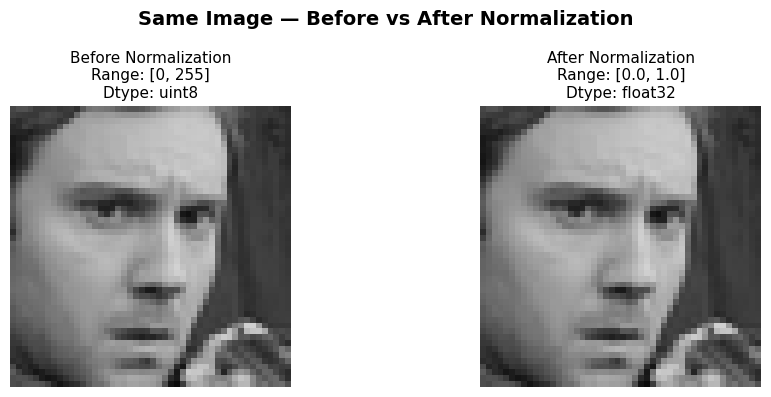

In [9]:
# Visual comparison: same image before and after normalization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(images[0], cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Before Normalization\nRange: [0, 255]\nDtype: {images.dtype}', fontsize=11)
axes[0].axis('off')

axes[1].imshow(images_normalized[0], cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'After Normalization\nRange: [0.0, 1.0]\nDtype: {images_normalized.dtype}', fontsize=11)
axes[1].axis('off')

plt.suptitle('Same Image — Before vs After Normalization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Step 3 — Convert Images to Tensors

Deep learning frameworks like TensorFlow require input data in **tensor format**. We:
1. Add a **channel dimension** — reshape from `(N, 48, 48)` to `(N, 48, 48, 1)` for grayscale.
2. Convert to **TensorFlow tensors** using `tf.constant()` or `tf.convert_to_tensor()`.
3. **One-hot encode** the labels for multi-class classification.

In [10]:
# Add channel dimension: (N, 48, 48) → (N, 48, 48, 1)
images_with_channel = np.expand_dims(images_normalized, axis=-1)

print('=== Adding Channel Dimension ===')
print(f'Before: {images_normalized.shape}  →  (samples, height, width)')
print(f'After:  {images_with_channel.shape}  →  (samples, height, width, channels)')
print(f'\nThe extra dimension (1) represents a single grayscale channel.')
print(f'For RGB images this would be 3 channels.')

=== Adding Channel Dimension ===
Before: (35340, 48, 48)  →  (samples, height, width)
After:  (35340, 48, 48, 1)  →  (samples, height, width, channels)

The extra dimension (1) represents a single grayscale channel.
For RGB images this would be 3 channels.


In [11]:
# Convert to TensorFlow tensors
image_tensor = tf.convert_to_tensor(images_with_channel, dtype=tf.float32)

print('=== Converting to TensorFlow Tensors ===')
print(f'Tensor shape : {image_tensor.shape}')
print(f'Tensor dtype  : {image_tensor.dtype}')
print(f'Is TF tensor  : {tf.is_tensor(image_tensor)}')
print(f'Device        : {image_tensor.device}')
print(f'\n✅ Step 3a Complete: Images converted to TensorFlow tensors')

=== Converting to TensorFlow Tensors ===
Tensor shape : (35340, 48, 48, 1)
Tensor dtype  : <dtype: 'float32'>
Is TF tensor  : True
Device        : /job:localhost/replica:0/task:0/device:CPU:0

✅ Step 3a Complete: Images converted to TensorFlow tensors


In [12]:
# One-hot encode the labels
NUM_CLASSES = 6
labels_onehot = tf.one_hot(labels, depth=NUM_CLASSES)

print('=== One-Hot Encoding Labels ===')
print(f'Original labels shape : {labels.shape}  (integer labels)')
print(f'One-hot labels shape  : {labels_onehot.shape}  (one-hot vectors)')
print(f'\nExample:')
print(f'  Label = {labels[0]} ({EMOTION_LABELS[labels[0]]})')
print(f'  One-hot = {labels_onehot[0].numpy()}')
print(f'\n✅ Step 3b Complete: Labels one-hot encoded')

=== One-Hot Encoding Labels ===
Original labels shape : (35340,)  (integer labels)
One-hot labels shape  : (35340, 6)  (one-hot vectors)

Example:
  Label = 0 (Angry)
  One-hot = [1. 0. 0. 0. 0. 0.]

✅ Step 3b Complete: Labels one-hot encoded


In [13]:
# Summary of tensor conversion
print('=' * 60)
print('TENSOR CONVERSION SUMMARY')
print('=' * 60)
print(f'\n  Image Tensor')
print(f'    Shape  : {image_tensor.shape}')
print(f'    Dtype  : {image_tensor.dtype}')
print(f'    Range  : [{tf.reduce_min(image_tensor).numpy():.1f}, {tf.reduce_max(image_tensor).numpy():.1f}]')
print(f'\n  Label Tensor')
print(f'    Shape  : {labels_onehot.shape}')
print(f'    Dtype  : {labels_onehot.dtype}')
print(f'    Classes: {NUM_CLASSES}')

TENSOR CONVERSION SUMMARY

  Image Tensor
    Shape  : (35340, 48, 48, 1)
    Dtype  : <dtype: 'float32'>
    Range  : [0.0, 1.0]

  Label Tensor
    Shape  : (35340, 6)
    Dtype  : <dtype: 'float32'>
    Classes: 6


---
## 6. Step 4 — Split Dataset into Training and Testing Sets

We split the preprocessed data into:
- **Training set (80%)** — Used to train the CNN model.
- **Testing set (20%)** — Used to evaluate the model's performance on unseen data.

We use `sklearn.model_selection.train_test_split` with `random_state=42` for reproducibility and `stratify` to maintain class balance in both splits.

In [14]:
# Split: 80% Training, 20% Testing
# Using numpy arrays for the split, then convert back to tensors
X_train, X_test, y_train, y_test = train_test_split(
    images_with_channel,       # Preprocessed images (numpy)
    labels,                     # Integer labels (for stratification)
    test_size=0.2,              # 20% for testing
    random_state=42,            # Reproducibility
    stratify=labels             # Maintain class proportions
)

# One-hot encode the split labels
y_train_onehot = tf.one_hot(y_train, depth=NUM_CLASSES)
y_test_onehot = tf.one_hot(y_test, depth=NUM_CLASSES)

print('✅ Step 4 Complete: Dataset Split into Training and Testing Sets')
print(f'\n  Split Ratio: 80% Training / 20% Testing')
print(f'  Random State: 42 (for reproducibility)')
print(f'  Stratified: Yes (class proportions maintained)')

✅ Step 4 Complete: Dataset Split into Training and Testing Sets

  Split Ratio: 80% Training / 20% Testing
  Random State: 42 (for reproducibility)
  Stratified: Yes (class proportions maintained)


In [15]:
# Detailed split summary
total = len(images_with_channel)

print('=' * 60)
print('TRAIN / TEST SPLIT SUMMARY')
print('=' * 60)
print(f'\n  Total samples     : {total}')
print(f'  Training samples  : {len(X_train)} ({len(X_train)/total*100:.1f}%)')
print(f'  Testing samples   : {len(X_test)} ({len(X_test)/total*100:.1f}%)')
print(f'\n  Training data shape : {X_train.shape}')
print(f'  Training labels     : {y_train_onehot.shape}')
print(f'  Testing data shape  : {X_test.shape}')
print(f'  Testing labels      : {y_test_onehot.shape}')

TRAIN / TEST SPLIT SUMMARY

  Total samples     : 35340
  Training samples  : 28272 (80.0%)
  Testing samples   : 7068 (20.0%)

  Training data shape : (28272, 48, 48, 1)
  Training labels     : (28272, 6)
  Testing data shape  : (7068, 48, 48, 1)
  Testing labels      : (7068, 6)


In [16]:
# Verify class balance in train and test sets
from collections import Counter

train_dist = Counter(y_train)
test_dist = Counter(y_test)

print('=' * 70)
print('CLASS DISTRIBUTION IN TRAIN vs TEST SETS')
print('=' * 70)
print(f'{"Class":<12} {"Train":>8} {"Train%":>8} {"Test":>8} {"Test%":>8}')
print('-' * 70)
for label_id in sorted(EMOTION_LABELS.keys()):
    name = EMOTION_LABELS[label_id]
    tr = train_dist.get(label_id, 0)
    te = test_dist.get(label_id, 0)
    tr_pct = tr / len(y_train) * 100
    te_pct = te / len(y_test) * 100
    print(f'{name:<12} {tr:>8} {tr_pct:>7.1f}% {te:>8} {te_pct:>7.1f}%')
print('-' * 70)
print(f'{"TOTAL":<12} {len(y_train):>8} {100.0:>7.1f}% {len(y_test):>8} {100.0:>7.1f}%')
print('\n✅ Class proportions are maintained in both sets (stratified split).')

CLASS DISTRIBUTION IN TRAIN vs TEST SETS
Class           Train   Train%     Test    Test%
----------------------------------------------------------------------
Angry            3962    14.0%      991    14.0%
Fear             4097    14.5%     1024    14.5%
Happy            7191    25.4%     1798    25.4%
Sad              4862    17.2%     1215    17.2%
Surprise         3202    11.3%      800    11.3%
Neutral          4958    17.5%     1240    17.5%
----------------------------------------------------------------------
TOTAL           28272   100.0%     7068   100.0%

✅ Class proportions are maintained in both sets (stratified split).


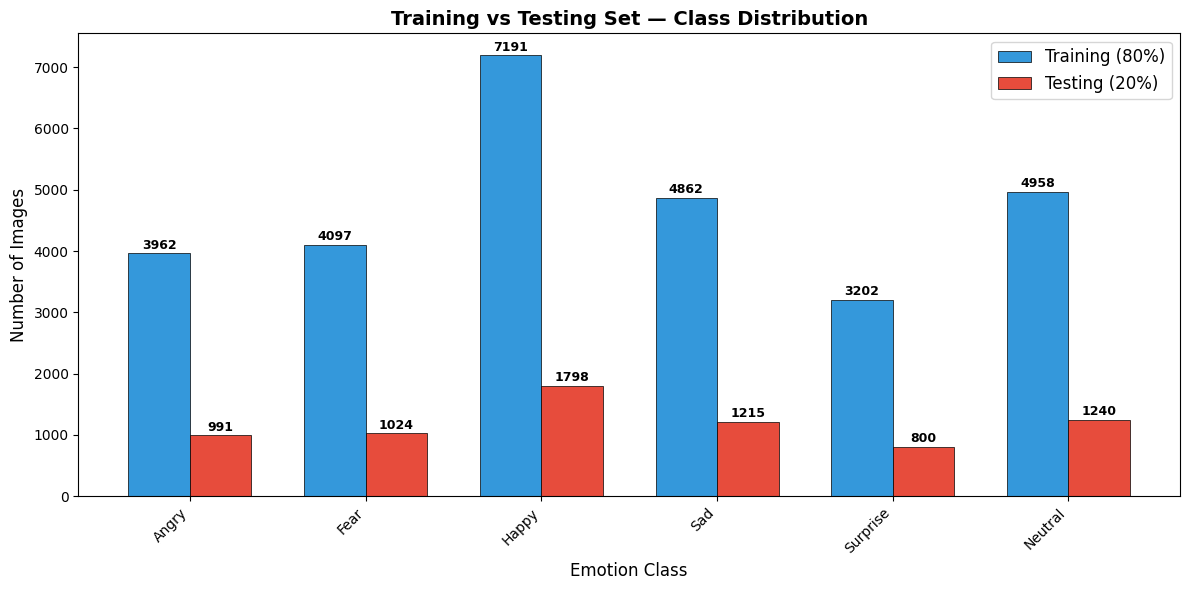

Chart saved as train_test_split.png


In [17]:
# Visualization: Train vs Test class distribution
colors = ['#FF6B6B', '#9B59B6', '#FFD93D', '#74B9FF', '#FFA502', '#00D2D3']
class_names = [EMOTION_LABELS[i] for i in sorted(EMOTION_LABELS.keys())]
train_counts = [train_dist.get(i, 0) for i in sorted(EMOTION_LABELS.keys())]
test_counts = [test_dist.get(i, 0) for i in sorted(EMOTION_LABELS.keys())]

x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, train_counts, width, label='Training (80%)', color='#3498DB', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, test_counts, width, label='Testing (20%)', color='#E74C3C', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Training vs Testing Set — Class Distribution', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend(fontsize=12)

# Add count labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as train_test_split.png')

---
## 7. Complete Preprocessing Pipeline Summary

In [18]:
print('=' * 65)
print('         COMPLETE PREPROCESSING PIPELINE SUMMARY')
print('=' * 65)
print(f'''
  Step 1: RESIZE IMAGES
    • Target size    : {TARGET_SIZE[0]} x {TARGET_SIZE[1]} pixels
    • Method         : cv2.resize() with INTER_AREA interpolation
    • Result         : All images are {TARGET_SIZE[0]}x{TARGET_SIZE[1]} pixels

  Step 2: NORMALIZE PIXEL VALUES
    • Before         : [0, 255] (uint8)
    • After          : [0.0, 1.0] (float32)
    • Formula        : pixel / 255.0
    • Purpose        : Faster convergence during training

  Step 3: CONVERT TO TENSORS
    • Image shape    : {X_train.shape[1:]}  (height, width, channels)
    • Image dtype    : float32
    • Label encoding : One-hot vectors (length = {NUM_CLASSES})
    • Framework      : TensorFlow {tf.__version__}

  Step 4: TRAIN/TEST SPLIT
    • Train samples  : {len(X_train)} ({len(X_train)/total*100:.1f}%)
    • Test samples   : {len(X_test)} ({len(X_test)/total*100:.1f}%)
    • Stratified     : Yes
    • Random state   : 42
''')
print('=' * 65)
print('Data is now ready for model training!')

         COMPLETE PREPROCESSING PIPELINE SUMMARY

  Step 1: RESIZE IMAGES
    • Target size    : 48 x 48 pixels
    • Method         : cv2.resize() with INTER_AREA interpolation
    • Result         : All images are 48x48 pixels

  Step 2: NORMALIZE PIXEL VALUES
    • Before         : [0, 255] (uint8)
    • After          : [0.0, 1.0] (float32)
    • Formula        : pixel / 255.0
    • Purpose        : Faster convergence during training

  Step 3: CONVERT TO TENSORS
    • Image shape    : (48, 48, 1)  (height, width, channels)
    • Image dtype    : float32
    • Label encoding : One-hot vectors (length = 6)
    • Framework      : TensorFlow 2.20.0

  Step 4: TRAIN/TEST SPLIT
    • Train samples  : 28272 (80.0%)
    • Test samples   : 7068 (20.0%)
    • Stratified     : Yes
    • Random state   : 42

Data is now ready for model training!


---
## 8. Summary Table

| Step | Operation | Before | After |
|------|-----------|--------|-------|
| 1 | Resize | Variable sizes | 48 × 48 pixels |
| 2 | Normalize | [0, 255] uint8 | [0.0, 1.0] float32 |
| 3 | Convert to Tensor | NumPy array (N, 48, 48) | TF Tensor (N, 48, 48, 1) |
| 4 | Train/Test Split | Full dataset | 80% Train / 20% Test (Stratified) |